In [ ]:
# Install required package
!pip install pillow-heif

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 60.4 MB/s eta 0:00:00


In [ ]:
import os
import glob
from PIL import Image
from pillow_heif import register_heif_opener

# Register HEIC opener with PIL so it can recognize the format
register_heif_opener()

folder_path = '/content/drive/MyDrive/sticker_project/'
image_files = glob.glob(os.path.join(folder_path, '*.jpeg')) + glob.glob(os.path.join(folder_path, '*.jpg'))

print("Starting conversion of Apple HEIC format to standard JPEG...")

fixed_count = 0
for file_path in image_files:
    file_name = os.path.basename(file_path)
    try:
        # Open the image (PIL can now read HEIC)
        with Image.open(file_path) as img:
            # Convert to standard RGB color mode
            img_rgb = img.convert('RGB')
            # Save as a true JPEG format, overwriting the original file
            img_rgb.save(file_path, format='JPEG')
            print(f"✅ Successfully converted and fixed: {file_name}")
            fixed_count += 1
    except Exception as e:
        print(f"❌ Conversion failed for: {file_name}, Error: {e}")

print(f"\nAwesome! Batch conversion completed! Successfully fixed {fixed_count} images.")

Starting conversion of Apple HEIC format to standard JPEG...
✅ Successfully converted and fixed: animal_26.jpeg
✅ Successfully converted and fixed: animal_6.jpeg
✅ Successfully converted and fixed: animal_16.jpeg
✅ Successfully converted and fixed: animal_27.jpeg
✅ Successfully converted and fixed: animal_13.jpeg
✅ Successfully converted and fixed: animal_8.jpeg
✅ Successfully converted and fixed: animal_19.jpeg
✅ Successfully converted and fixed: animal_15.jpeg
✅ Successfully converted and fixed: animal_28.jpeg
✅ Successfully converted and fixed: animal_12.jpeg
✅ Successfully converted and fixed: animal_11.jpeg
✅ Successfully converted and fixed: animal_36.jpeg
✅ Successfully converted and fixed: animal_17.jpeg
✅ Successfully converted and fixed: animal_7.jpeg
✅ Successfully converted and fixed: animal_9.jpeg
✅ Successfully converted and fixed: animal_2.jpeg
✅ Successfully converted and fixed: animal_1.jpeg
✅ Successfully converted and fixed: animal_18.jpeg
✅ Successfully converted an

In [ ]:
import os
import json
import re
import torch
from diffusers import StableDiffusionPipeline
from google.colab import drive
from PIL import Image

# Mount Drive
try:
    drive.mount('/content/drive')
except ValueError:
    print("✅ Drive already mounted")

class Config:
    drive_path = "/content/drive/MyDrive/sticker_project"
    lora_path = "/content/drive/MyDrive/lora_flat"
    output_folder = "/content/drive/MyDrive/sticker_results"
    json_path = "/content/drive/MyDrive/batch_sticker_prompts.json"

    pretrained_model_name = "runwayml/stable-diffusion-v1-5"

    num_inference_steps = 50
    guidance_scale = 7.5

def load_lora_with_peft(pipe, lora_path):
    """Load LoRA using PEFT"""
    try:
        from peft import PeftModel
        print(f"🔄 Loading LoRA from: {lora_path}")
        pipe.unet = PeftModel.from_pretrained(pipe.unet, lora_path)
        print(f"✅ LoRA loaded successfully")
        return True
    except Exception as e:
        print(f"❌ Failed to load LoRA: {e}")
        return False

def extract_number_from_filename(filename):
    """
    Extract number from filename
    Example: 'animal_42.jpg' → '42'
             'animal_001.jpg' → '001'
    """
    # Remove file extension
    base_name = os.path.splitext(filename)[0]
    # Extract the number part after 'animal_'
    match = re.search(r'animal_(\d+)', base_name)
    if match:
        return match.group(1)
    return None

def main():
    config = Config()

    # Load base model
    print(f"📥 Loading base model...")
    pipe = StableDiffusionPipeline.from_pretrained(
        config.pretrained_model_name,
        torch_dtype=torch.float16,
        safety_checker=None,
    ).to("cuda")

    pipe.enable_attention_slicing()
    print(f"✅ Base model loaded")

    # Load LoRA
    if not load_lora_with_peft(pipe, config.lora_path):
        print("❌ Cannot proceed without LoRA")
        return

    # Create output directory
    os.makedirs(config.output_folder, exist_ok=True)

    # Load prompts
    if not os.path.exists(config.json_path):
        print(f"❌ JSON not found: {config.json_path}")
        return

    with open(config.json_path, 'r', encoding='utf-8') as f:
        prompts_data = json.load(f)

    if isinstance(prompts_data, dict):
        prompts_list = list(prompts_data.values())
    else:
        prompts_list = prompts_data

    total = len(prompts_list)
    print(f"\n{'='*60}")
    print(f"Starting generation for {total} images...")
    print(f"{'='*60}\n")

    success = 0
    failed = 0

    # Batch generation
    for i, item in enumerate(prompts_list, start=1):
        prompt = item['sd_sticker_prompt']
        original_file = item['file_name']

        # Extract number from original filename
        number = extract_number_from_filename(original_file)

        if number is None:
            print(f"[{i}/{total}] ⚠️ Cannot extract number from: {original_file}")
            failed += 1
            continue

        # Generate corresponding output filename: flat_animal_{number}.png
        output_file = f"flat_animal_{number}.png"
        save_path = os.path.join(config.output_folder, output_file)

        print(f"[{i}/{total}] {original_file} → {output_file}")
        print(f"📝 Prompt: {prompt}")  # 🆕 Display prompt

        try:
            image = pipe(
                prompt,
                num_inference_steps=config.num_inference_steps,
                guidance_scale=config.guidance_scale,
            ).images[0]

            image.save(save_path)
            print(f"✅ Saved\n")
            success += 1

        except Exception as e:
            print(f"❌ Failed: {e}\n")
            failed += 1

    # Statistics
    print(f"{'='*60}")
    print(f"🎉 Complete!")
    print(f"✅ Success: {success}/{total}")
    if failed > 0:
        print(f"❌ Failed: {failed}")
    print(f"📁 Output: {config.output_folder}")
    print(f"{'='*60}")

# Run
main()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📥 Loading base model...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its resul

✅ Base model loaded
🔄 Loading LoRA from: /content/drive/MyDrive/lora_flat
✅ LoRA loaded successfully

Starting generation for 37 images...

[1/37] animal_2.jpeg → flat_animal_2.png
📝 Prompt: Two sks cats, one sitting and looking at the camera while the other is lying down, sticker style.


...

✅ Saved

[36/37] animal_30.jpeg → flat_animal_30.png
📝 Prompt: A gray sks cat lying down with a relaxed expression, sticker style.


  0%|          | 0/50 [00:00<?, ?it/s]

✅ Saved

[37/37] animal_20.jpeg → flat_animal_20.png
📝 Prompt: A relaxed gray tabby sks cat lying down, looking at camera, sticker style.


  0%|          | 0/50 [00:00<?, ?it/s]

✅ Saved

🎉 Complete!
✅ Success: 37/37
📁 Output: /content/drive/MyDrive/sticker_results


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📥 Loading base model...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its resul

✅ Base model loaded
🔄 Loading LoRA from: /content/drive/MyDrive/lora_flat
✅ LoRA loaded successfully

📝 Original file: animal_13.jpeg
📝 Output file: flat_animal_13.png
📝 Prompt: A curious sks cow facing the camera in sticker style.

⚠️  File already exists: /content/drive/MyDrive/sticker_results/flat_animal_13.png
    It will be replaced.

🎨 Generating image...


  0%|          | 0/50 [00:00<?, ?it/s]

✅ Successfully saved to: /content/drive/MyDrive/sticker_results/flat_animal_13.png


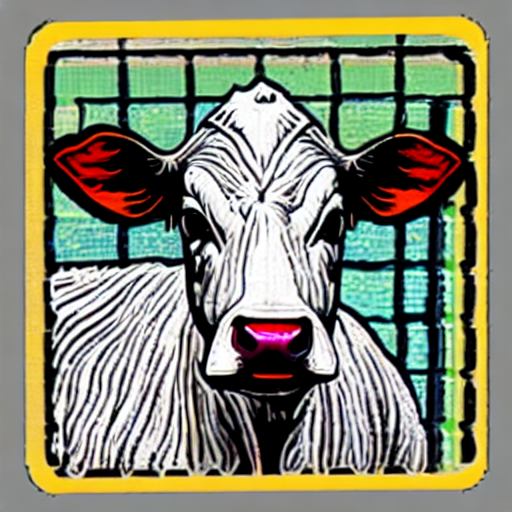

True

In [ ]:
import os
import json
import re
import torch
from diffusers import StableDiffusionPipeline
from google.colab import drive
from PIL import Image

# Mount Drive
try:
    drive.mount('/content/drive')
except ValueError:
    print("✅ Drive already mounted")

class Config:
    drive_path = "/content/drive/MyDrive/sticker_project"
    lora_path = "/content/drive/MyDrive/lora_flat"
    output_folder = "/content/drive/MyDrive/sticker_results"
    json_path = "/content/drive/MyDrive/batch_sticker_prompts.json"

    pretrained_model_name = "runwayml/stable-diffusion-v1-5"

    num_inference_steps = 50
    guidance_scale = 7.5

def load_lora_with_peft(pipe, lora_path):
    """Load LoRA using PEFT"""
    try:
        from peft import PeftModel
        print(f"🔄 Loading LoRA from: {lora_path}")
        pipe.unet = PeftModel.from_pretrained(pipe.unet, lora_path)
        print(f"✅ LoRA loaded successfully")
        return True
    except Exception as e:
        print(f"❌ Failed to load LoRA: {e}")
        return False

def extract_number_from_filename(filename):
    """
    Extract number from filename
    Example: 'animal_42.jpg' → '42'
             'animal_001.jpg' → '001'
    """
    base_name = os.path.splitext(filename)[0]
    match = re.search(r'animal_(\d+)', base_name)
    if match:
        return match.group(1)
    return None

def find_prompt_by_number(prompts_list, target_number):
    """
    Find corresponding prompt by number
    Returns: (prompt, original_filename) or (None, None)
    """
    for item in prompts_list:
        filename = item['file_name']
        number = extract_number_from_filename(filename)

        if number == str(target_number):
            return item['sd_sticker_prompt'], filename

    return None, None

def generate_single_image(target_number):
    """Generate a single image for the specified number"""
    config = Config()

    # Load base model
    print(f"📥 Loading base model...")
    pipe = StableDiffusionPipeline.from_pretrained(
        config.pretrained_model_name,
        torch_dtype=torch.float16,
        safety_checker=None,
    ).to("cuda")

    pipe.enable_attention_slicing()
    print(f"✅ Base model loaded")

    # Load LoRA
    if not load_lora_with_peft(pipe, config.lora_path):
        print("❌ Cannot proceed without LoRA")
        return False

    # Create output directory
    os.makedirs(config.output_folder, exist_ok=True)

    # Load prompts
    if not os.path.exists(config.json_path):
        print(f"❌ JSON not found: {config.json_path}")
        return False

    with open(config.json_path, 'r', encoding='utf-8') as f:
        prompts_data = json.load(f)

    if isinstance(prompts_data, dict):
        prompts_list = list(prompts_data.values())
    else:
        prompts_list = prompts_data

    # Find corresponding prompt
    prompt, original_file = find_prompt_by_number(prompts_list, target_number)

    if prompt is None:
        print(f"❌ No prompt found for number: {target_number}")
        print(f"💡 Available numbers:")
        available_numbers = []
        for item in prompts_list:
            num = extract_number_from_filename(item['file_name'])
            if num:
                available_numbers.append(num)
        print(f"   {', '.join(sorted(available_numbers, key=lambda x: int(x)))}")
        return False

    # Generate output filename
    output_file = f"flat_animal_{target_number}.png"
    save_path = os.path.join(config.output_folder, output_file)

    print(f"\n{'='*60}")
    print(f"📝 Original file: {original_file}")
    print(f"📝 Output file: {output_file}")
    print(f"📝 Prompt: {prompt}")
    print(f"{'='*60}\n")

    # Check if file already exists
    if os.path.exists(save_path):
        print(f"⚠️  File already exists: {save_path}")
        print(f"    It will be replaced.\n")

    # Generate image
    try:
        print(f"🎨 Generating image...")
        image = pipe(
            prompt,
            num_inference_steps=config.num_inference_steps,
            guidance_scale=config.guidance_scale,
        ).images[0]

        image.save(save_path)
        print(f"✅ Successfully saved to: {save_path}")

        # Show image preview
        from IPython.display import display
        display(image)

        return True

    except Exception as e:
        print(f"❌ Generation failed: {e}")
        return False

# =========================
# 🎯 Usage: Modify the number here
# =========================

# Method 1: Specify the number directly
TARGET_NUMBER = "13"  # 👈 Modify the number here

# Run generation
generate_single_image(TARGET_NUMBER)

# =========================
# Method 2: Generate multiple specified numbers (Optional)
# =========================
# target_numbers = ["42", "108", "255"]  # List of numbers to regenerate
# for num in target_numbers:
#     print(f"\n{'🔄 Processing number: ' + num:=^60}\n")
#     generate_single_image(num)

In [ ]:
import os
import json
import re
import torch
from diffusers import StableDiffusionPipeline
from google.colab import drive
from PIL import Image
import warnings

# Ignore safety checker warnings
warnings.filterwarnings('ignore', message='.*safety checker.*')

# Mount Drive
try:
    drive.mount('/content/drive')
except ValueError:
    print("✅ Drive already mounted")

class Config:
    drive_path = "/content/drive/MyDrive/sticker_project"

    # ✅ Use HuggingFace repository ID
    lora_repo_id = "Lilian0703/sticker-lora-cartoon"

    output_folder = "/content/drive/MyDrive/sticker_results"
    json_path = "/content/drive/MyDrive/batch_sticker_prompts.json"

    pretrained_model_name = "runwayml/stable-diffusion-v1-5"

    num_inference_steps = 50
    guidance_scale = 7.5

    # ✅ LoRA strength (optional, default 1.0)
    lora_scale = 1.0

def extract_number_from_filename(filename):
    """Extract number from filename"""
    base_name = os.path.splitext(filename)[0]
    match = re.search(r'animal_(\d+)', base_name)
    if match:
        return match.group(1)
    return None

def main():
    config = Config()

    # Load base model
    print(f"📥 Loading base model...")
    pipe = StableDiffusionPipeline.from_pretrained(
        config.pretrained_model_name,
        torch_dtype=torch.float16,
        safety_checker=None,
    ).to("cuda")

    pipe.enable_attention_slicing()
    print(f"✅ Base model loaded")

    # ✅ Load LoRA using HuggingFace method
    print(f"🔄 Loading LoRA from HuggingFace: {config.lora_repo_id}")
    try:
        pipe.load_lora_weights(config.lora_repo_id)
        print(f"✅ LoRA loaded successfully")

        # ✅ Set LoRA strength
        adapter_names = pipe.get_list_adapters()
        if adapter_names and "unet" in adapter_names:
            adapter_name = adapter_names["unet"][0]
            pipe.set_adapters([adapter_name], adapter_weights=[config.lora_scale])
            print(f"⚙️  LoRA scale set to {config.lora_scale}")

    except Exception as e:
        print(f"❌ Failed to load LoRA: {e}")
        response = input("Continue without LoRA? (y/n): ")
        if response.lower() != 'y':
            return

    # Create output directory
    os.makedirs(config.output_folder, exist_ok=True)

    # Load prompts
    if not os.path.exists(config.json_path):
        print(f"❌ JSON not found: {config.json_path}")
        return

    with open(config.json_path, 'r', encoding='utf-8') as f:
        prompts_data = json.load(f)

    if isinstance(prompts_data, dict):
        prompts_list = list(prompts_data.values())
    else:
        prompts_list = prompts_data

    total = len(prompts_list)
    print(f"\n{'='*60}")
    print(f"🎨 Starting generation for {total} images...")
    print(f"{'='*60}\n")

    success = 0
    failed = 0

    # Batch generation
    for i, item in enumerate(prompts_list, start=1):
        prompt = item['sd_sticker_prompt']
        original_file = item['file_name']

        # Extract number from original filename
        number = extract_number_from_filename(original_file)

        if number is None:
            print(f"[{i}/{total}] ⚠️  Cannot extract number from: {original_file}")
            failed += 1
            continue

        # Generate corresponding output filename
        output_file = f"cartoon_animal_{number}.png"
        save_path = os.path.join(config.output_folder, output_file)

        print(f"[{i}/{total}] {original_file} → {output_file}")
        print(f"         📝 {prompt}")

        try:
            image = pipe(
                prompt=prompt,
                num_inference_steps=config.num_inference_steps,
                guidance_scale=config.guidance_scale,
            ).images[0]

            image.save(save_path)
            print(f"         ✅ Saved\n")
            success += 1

        except Exception as e:
            print(f"         ❌ Failed: {e}\n")
            failed += 1

    # Final statistics
    print(f"{'='*60}")
    print(f"🎉 Generation Complete!")
    print(f"✅ Success: {success}/{total}")
    if failed > 0:
        print(f"❌ Failed: {failed}")
    print(f"📁 Output folder: {config.output_folder}")
    print(f"{'='*60}")

# Run
main()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📥 Loading base model...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its resul

✅ Base model loaded
🔄 Loading LoRA from HuggingFace: Lilian0703/sticker-lora-cartoon


...

         ✅ Saved

[36/37] animal_30.jpeg → cartoon_animal_30.png
         📝 A gray sks cat lying down with a relaxed expression, sticker style.


  0%|          | 0/50 [00:00<?, ?it/s]

         ✅ Saved

[37/37] animal_20.jpeg → cartoon_animal_20.png
         📝 A relaxed gray tabby sks cat lying down, looking at camera, sticker style.


  0%|          | 0/50 [00:00<?, ?it/s]

         ✅ Saved

🎉 Generation Complete!
✅ Success: 37/37
📁 Output folder: /content/drive/MyDrive/sticker_results


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📥 Loading base model...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its resul

✅ Base model loaded
🔄 Loading LoRA from HuggingFace: Lilian0703/sticker-lora-cartoon


No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


✅ LoRA loaded successfully
⚙️  LoRA scale set to 1.0

🎨 Starting batch generation for 1 images...


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🔄 Processing [1/1] number: 32
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📝 Original file: animal_32.jpeg
📝 Output file:   cartoon_animal_32.png
📝 Prompt:        A sleek grey sks cat lying down. sticker style.

⚠️  File already exists: cartoon_animal_32.png
    It will be REPLACED.

🎨 Generating image...


  0%|          | 0/50 [00:00<?, ?it/s]

✅ Successfully saved to: /content/drive/MyDrive/sticker_results/cartoon_animal_32.png

🖼️  Preview:


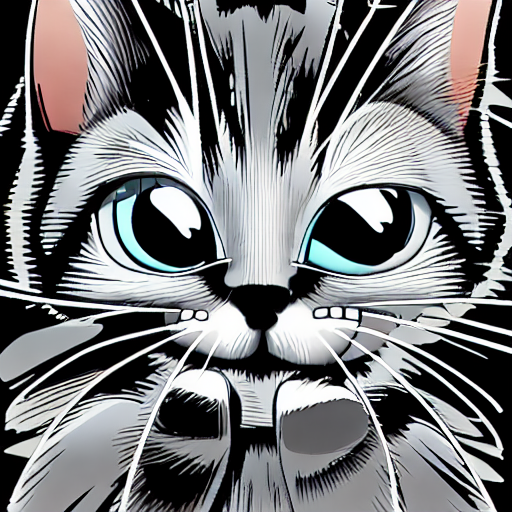


🎉 Batch Generation Complete!
✅ Success: 1/1
📁 Output folder: /content/drive/MyDrive/sticker_results


In [ ]:
import os
import json
import re
import torch
from diffusers import StableDiffusionPipeline
from google.colab import drive
from PIL import Image
import warnings

# Ignore safety checker warnings
warnings.filterwarnings('ignore', message='.*safety checker.*')

# Mount Drive
try:
    drive.mount('/content/drive')
except ValueError:
    print("✅ Drive already mounted")

class Config:
    drive_path = "/content/drive/MyDrive/sticker_project"

    # ✅ Use HuggingFace repository ID
    lora_repo_id = "Lilian0703/sticker-lora-cartoon"

    output_folder = "/content/drive/MyDrive/sticker_results"
    json_path = "/content/drive/MyDrive/batch_sticker_prompts.json"

    pretrained_model_name = "runwayml/stable-diffusion-v1-5"

    num_inference_steps = 50
    guidance_scale = 7.5

    # ✅ LoRA strength (optional, default 1.0)
    lora_scale = 1.0

def extract_number_from_filename(filename):
    """Extract number from filename"""
    base_name = os.path.splitext(filename)[0]
    match = re.search(r'animal_(\d+)', base_name)
    if match:
        return match.group(1)
    return None

def find_prompt_by_number(prompts_list, target_number):
    """
    Find corresponding prompt by number
    Returns: (prompt, original_filename) or (None, None)
    """
    for item in prompts_list:
        filename = item['file_name']
        number = extract_number_from_filename(filename)

        if number == str(target_number):
            return item['sd_sticker_prompt'], filename

    return None, None

def generate_single_image(target_number, pipe=None, prompts_list=None):
    """
    Generate a single image for a specific number

    Parameters:
        target_number: The number to generate
        pipe: Optional, loaded pipeline (to avoid reloading during batch generation)
        prompts_list: Optional, loaded prompts list
    """
    config = Config()

    # Load pipeline if not provided
    need_cleanup = False
    if pipe is None:
        need_cleanup = True

        # Load base model
        print(f"📥 Loading base model...")
        pipe = StableDiffusionPipeline.from_pretrained(
            config.pretrained_model_name,
            torch_dtype=torch.float16,
            safety_checker=None,
        ).to("cuda")

        pipe.enable_attention_slicing()
        print(f"✅ Base model loaded")

        # ✅ Load LoRA using HuggingFace method
        print(f"🔄 Loading LoRA from HuggingFace: {config.lora_repo_id}")
        try:
            pipe.load_lora_weights(config.lora_repo_id)
            print(f"✅ LoRA loaded successfully")

            # ✅ Set LoRA strength
            adapter_names = pipe.get_list_adapters()
            if adapter_names and "unet" in adapter_names:
                adapter_name = adapter_names["unet"][0]
                pipe.set_adapters([adapter_name], adapter_weights=[config.lora_scale])
                print(f"⚙️  LoRA scale set to {config.lora_scale}")

        except Exception as e:
            print(f"❌ Failed to load LoRA: {e}")
            print(f"⚠️  Continuing without LoRA...")

    # Create output directory
    os.makedirs(config.output_folder, exist_ok=True)

    # Load prompts_list if not provided
    if prompts_list is None:
        if not os.path.exists(config.json_path):
            print(f"❌ JSON not found: {config.json_path}")
            return False

        with open(config.json_path, 'r', encoding='utf-8') as f:
            prompts_data = json.load(f)

        if isinstance(prompts_data, dict):
            prompts_list = list(prompts_data.values())
        else:
            prompts_list = prompts_data

    # Find corresponding prompt
    prompt, original_file = find_prompt_by_number(prompts_list, target_number)

    if prompt is None:
        print(f"❌ No prompt found for number: {target_number}")
        print(f"\n💡 Available numbers:")
        available_numbers = []
        for item in prompts_list:
            num = extract_number_from_filename(item['file_name'])
            if num:
                available_numbers.append(num)

        # Display sorted by number
        available_numbers.sort(key=lambda x: int(x))
        print(f"   {', '.join(available_numbers)}")
        return False

    # Generate filename
    output_file = f"cartoon_animal_{target_number}.png"
    save_path = os.path.join(config.output_folder, output_file)

    print(f"\n{'='*60}")
    print(f"📝 Original file: {original_file}")
    print(f"📝 Output file:   {output_file}")
    print(f"📝 Prompt:        {prompt}")
    print(f"{'='*60}\n")

    # Check if file already exists
    if os.path.exists(save_path):
        print(f"⚠️  File already exists: {output_file}")
        print(f"    It will be REPLACED.\n")

    # Generate image
    try:
        print(f"🎨 Generating image...")
        image = pipe(
            prompt=prompt,
            num_inference_steps=config.num_inference_steps,
            guidance_scale=config.guidance_scale,
        ).images[0]

        image.save(save_path)
        print(f"✅ Successfully saved to: {save_path}\n")

        # Display image preview
        try:
            from IPython.display import display
            print("🖼️  Preview:")
            display(image)
        except:
            pass  # Skip if not in a notebook environment

        return True

    except Exception as e:
        print(f"❌ Generation failed: {e}")
        import traceback
        traceback.print_exc()
        return False
    finally:
        # Clean up GPU memory if it's a single generation
        if need_cleanup:
            del pipe
            torch.cuda.empty_cache()

def batch_generate(target_numbers):
    """
    Batch generate multiple images (efficient version, loads model only once)

    Parameters:
        target_numbers: List of numbers, e.g., ["5", "6", "7"]
    """
    config = Config()

    # Load base model (load only once)
    print(f"📥 Loading base model...")
    pipe = StableDiffusionPipeline.from_pretrained(
        config.pretrained_model_name,
        torch_dtype=torch.float16,
        safety_checker=None,
    ).to("cuda")

    pipe.enable_attention_slicing()
    print(f"✅ Base model loaded")

    # ✅ Load LoRA using HuggingFace method
    print(f"🔄 Loading LoRA from HuggingFace: {config.lora_repo_id}")
    try:
        pipe.load_lora_weights(config.lora_repo_id)
        print(f"✅ LoRA loaded successfully")

        # ✅ Set LoRA strength
        adapter_names = pipe.get_list_adapters()
        if adapter_names and "unet" in adapter_names:
            adapter_name = adapter_names["unet"][0]
            pipe.set_adapters([adapter_name], adapter_weights=[config.lora_scale])
            print(f"⚙️  LoRA scale set to {config.lora_scale}")

    except Exception as e:
        print(f"❌ Failed to load LoRA: {e}")
        print(f"⚠️  Continuing without LoRA...")

    # Load prompts (load only once)
    if not os.path.exists(config.json_path):
        print(f"❌ JSON not found: {config.json_path}")
        return

    with open(config.json_path, 'r', encoding='utf-8') as f:
        prompts_data = json.load(f)

    if isinstance(prompts_data, dict):
        prompts_list = list(prompts_data.values())
    else:
        prompts_list = prompts_data

    # Batch generation
    total = len(target_numbers)
    success = 0
    failed = 0

    print(f"\n{'='*60}")
    print(f"🎨 Starting batch generation for {total} images...")
    print(f"{'='*60}\n")

    for i, num in enumerate(target_numbers, start=1):
        print(f"\n{'━'*60}")
        print(f"🔄 Processing [{i}/{total}] number: {num}")
        print(f"{'━'*60}")

        result = generate_single_image(num, pipe=pipe, prompts_list=prompts_list)

        if result:
            success += 1
        else:
            failed += 1
            print(f"⚠️  Skipped number: {num}")

    # Final statistics
    print(f"\n{'='*60}")
    print(f"🎉 Batch Generation Complete!")
    print(f"✅ Success: {success}/{total}")
    if failed > 0:
        print(f"❌ Failed: {failed}")
    print(f"📁 Output folder: {config.output_folder}")
    print(f"{'='*60}")

    # Clean up memory
    del pipe
    torch.cuda.empty_cache()

# =========================
# 🎯 Usage
# =========================

# Method 1: Generate a single image
# TARGET_NUMBER = "42"  # 👈 Modify the number here
# generate_single_image(TARGET_NUMBER)

# =========================
# Method 2: Batch regenerate multiple images (batch_generate is recommended)
# =========================
target_numbers = ["32"]
batch_generate(target_numbers)

In [ ]:
import os
import json
import re
import torch
from diffusers import StableDiffusionPipeline
from google.colab import drive
from PIL import Image
import warnings

# Ignore safety checker warnings
warnings.filterwarnings('ignore', message='.*safety checker.*')

# Mount Drive
try:
    drive.mount('/content/drive')
except ValueError:
    print("✅ Drive already mounted")

class Config:
    drive_path = "/content/drive/MyDrive/sticker_project"

    # ✅ Modify to watercolor style LoRA
    lora_repo_id = "Lilian0703/sticker-lora-watercolor"

    output_folder = "/content/drive/MyDrive/sticker_results"  # Modify output folder name
    json_path = "/content/drive/MyDrive/batch_sticker_prompts.json"

    pretrained_model_name = "runwayml/stable-diffusion-v1-5"

    num_inference_steps = 50
    guidance_scale = 7.5

    # ✅ LoRA strength (watercolor style may need adjustment)
    lora_scale = 1.0  # Can try between 0.7-1.2

def extract_number_from_filename(filename):
    """Extract number from filename"""
    base_name = os.path.splitext(filename)[0]
    match = re.search(r'animal_(\d+)', base_name)
    if match:
        return match.group(1)
    return None

def main():
    config = Config()

    # Load base model
    print(f"📥 Loading base model...")
    pipe = StableDiffusionPipeline.from_pretrained(
        config.pretrained_model_name,
        torch_dtype=torch.float16,
        safety_checker=None,
    ).to("cuda")

    pipe.enable_attention_slicing()
    print(f"✅ Base model loaded")

    # ✅ Load watercolor style LoRA
    print(f"🎨 Loading Watercolor LoRA from: {config.lora_repo_id}")
    try:
        pipe.load_lora_weights(config.lora_repo_id)
        print(f"✅ Watercolor LoRA loaded successfully")

        # ✅ Set LoRA strength
        adapter_names = pipe.get_list_adapters()
        if adapter_names and "unet" in adapter_names:
            adapter_name = adapter_names["unet"][0]
            pipe.set_adapters([adapter_name], adapter_weights=[config.lora_scale])
            print(f"⚙️  LoRA scale set to {config.lora_scale}")

    except Exception as e:
        print(f"❌ Failed to load LoRA: {e}")
        response = input("Continue without LoRA? (y/n): ")
        if response.lower() != 'y':
            return

    # Create output directory
    os.makedirs(config.output_folder, exist_ok=True)

    # Load prompts
    if not os.path.exists(config.json_path):
        print(f"❌ JSON not found: {config.json_path}")
        return

    with open(config.json_path, 'r', encoding='utf-8') as f:
        prompts_data = json.load(f)

    if isinstance(prompts_data, dict):
        prompts_list = list(prompts_data.values())
    else:
        prompts_list = prompts_data

    total = len(prompts_list)
    print(f"\n{'='*60}")
    print(f"🎨 Starting Watercolor Style Generation for {total} images...")
    print(f"{'='*60}\n")

    success = 0
    failed = 0

    # Batch generation
    for i, item in enumerate(prompts_list, start=1):
        prompt = item['sd_sticker_prompt']
        original_file = item['file_name']

        # Extract number from original filename
        number = extract_number_from_filename(original_file)

        if number is None:
            print(f"[{i}/{total}] ⚠️  Cannot extract number from: {original_file}")
            failed += 1
            continue

        # ✅ Modify output filename prefix to watercolor
        output_file = f"watercolor_animal_{number}.png"
        save_path = os.path.join(config.output_folder, output_file)

        print(f"[{i}/{total}] {original_file} → {output_file}")
        print(f"         📝 {prompt}")

        try:
            image = pipe(
                prompt=prompt,
                num_inference_steps=config.num_inference_steps,
                guidance_scale=config.guidance_scale,
            ).images[0]

            image.save(save_path)
            print(f"         ✅ Saved\n")
            success += 1

        except Exception as e:
            print(f"         ❌ Failed: {e}\n")
            failed += 1

    # Final statistics
    print(f"{'='*60}")
    print(f"🎉 Watercolor Generation Complete!")
    print(f"✅ Success: {success}/{total}")
    if failed > 0:
        print(f"❌ Failed: {failed}")
    print(f"📁 Output folder: {config.output_folder}")
    print(f"{'='*60}")

# Run
main()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📥 Loading base model...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its resul

✅ Base model loaded
🎨 Loading Watercolor LoRA from: Lilian0703/sticker-lora-watercolor


...

         ✅ Saved

[36/37] animal_30.jpeg → watercolor_animal_30.png
         📝 A gray sks cat lying down with a relaxed expression, sticker style.


  0%|          | 0/50 [00:00<?, ?it/s]

         ✅ Saved

[37/37] animal_20.jpeg → watercolor_animal_20.png
         📝 A relaxed gray tabby sks cat lying down, looking at camera, sticker style.


  0%|          | 0/50 [00:00<?, ?it/s]

         ✅ Saved

🎉 Watercolor Generation Complete!
✅ Success: 37/37
📁 Output folder: /content/drive/MyDrive/sticker_results


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📥 Loading base model...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its resul

✅ Base model loaded
🎨 Loading Watercolor LoRA from: Lilian0703/sticker-lora-watercolor


No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


✅ Watercolor LoRA loaded successfully
⚙️  LoRA scale set to 1.0

🎨 Starting Watercolor Regeneration (OVERWRITE MODE)
📊 Total images: 2
🎯 Target numbers: 15, 20
⚠️  Existing files will be OVERWRITTEN


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🔄 Processing [1/2] number: 15
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📝 Original file: animal_15.jpeg
📝 Output file:   watercolor_animal_15.png
📝 Prompt:        A curious gray sks cat looking at the camera with its eyes wide open, sticker style.
🎨 Style:         Watercolor

⚠️  File already exists: watercolor_animal_15.png
    It will be OVERWRITTEN (regenerated).

🎨 Generating watercolor image...


  0%|          | 0/50 [00:00<?, ?it/s]

✅ Successfully saved to: /content/drive/MyDrive/sticker_results/watercolor_animal_15.png

🖼️  Preview:


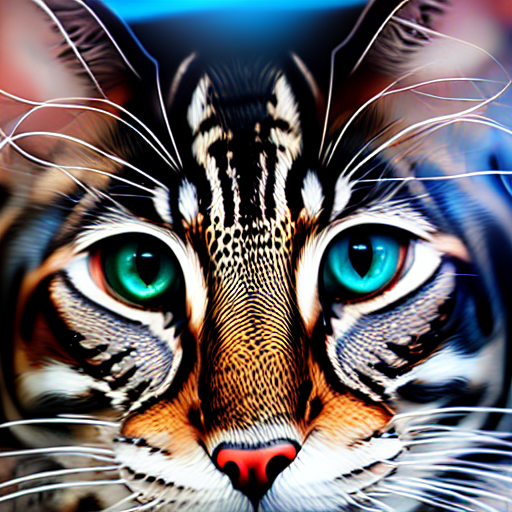


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🔄 Processing [2/2] number: 20
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📝 Original file: animal_20.jpeg
📝 Output file:   watercolor_animal_20.png
📝 Prompt:        A relaxed gray tabby sks cat lying down, looking at camera, sticker style.
🎨 Style:         Watercolor

⚠️  File already exists: watercolor_animal_20.png
    It will be OVERWRITTEN (regenerated).

🎨 Generating watercolor image...


  0%|          | 0/50 [00:00<?, ?it/s]

✅ Successfully saved to: /content/drive/MyDrive/sticker_results/watercolor_animal_20.png

🖼️  Preview:


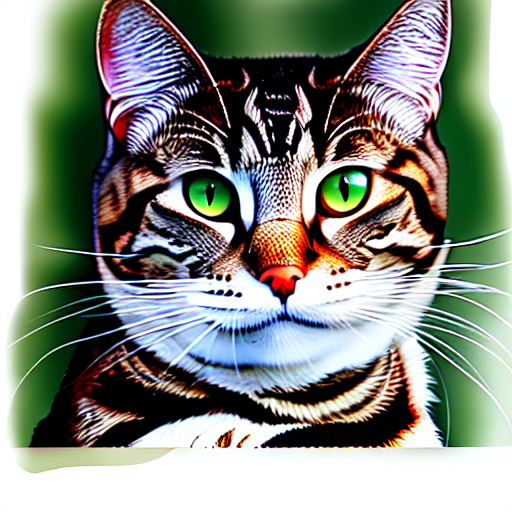


🎉 Watercolor Regeneration Complete!
✅ Success: 2/2
📁 Output folder: /content/drive/MyDrive/sticker_results


In [ ]:
import os
import json
import re
import torch
from diffusers import StableDiffusionPipeline
from google.colab import drive
from PIL import Image
import warnings

# Ignore safety checker warnings
warnings.filterwarnings('ignore', message='.*safety checker.*')

# Mount Drive
try:
    drive.mount('/content/drive')
except ValueError:
    print("✅ Drive already mounted")

class Config:
    drive_path = "/content/drive/MyDrive/sticker_project"

    # ✅ Watercolor style LoRA
    lora_repo_id = "Lilian0703/sticker-lora-watercolor"

    output_folder = "/content/drive/MyDrive/sticker_results"
    json_path = "/content/drive/MyDrive/batch_sticker_prompts.json"

    pretrained_model_name = "runwayml/stable-diffusion-v1-5"

    num_inference_steps = 50
    guidance_scale = 7.5

    # ✅ LoRA strength (0.8-1.2 recommended for watercolor style)
    lora_scale = 1.0

def extract_number_from_filename(filename):
    """Extract number from filename"""
    base_name = os.path.splitext(filename)[0]
    match = re.search(r'animal_(\d+)', base_name)
    if match:
        return int(match.group(1))  # Return integer
    return None

def find_prompt_by_number(prompts_list, target_number):
    """
    Find the corresponding prompt by number
    Returns: (prompt, original_filename) or (None, None)
    """
    for item in prompts_list:
        filename = item['file_name']
        number = extract_number_from_filename(filename)

        if number == target_number:
            return item['sd_sticker_prompt'], filename

    return None, None

def load_pipeline_once(config):
    """
    Load model and LoRA (load only once)
    Returns: pipeline or None (if loading fails)
    """
    print(f"📥 Loading base model...")
    pipe = StableDiffusionPipeline.from_pretrained(
        config.pretrained_model_name,
        torch_dtype=torch.float16,
        safety_checker=None,
    ).to("cuda")

    pipe.enable_attention_slicing()
    print(f"✅ Base model loaded")

    # ✅ Load watercolor style LoRA
    print(f"🎨 Loading Watercolor LoRA from: {config.lora_repo_id}")
    try:
        pipe.load_lora_weights(config.lora_repo_id)
        print(f"✅ Watercolor LoRA loaded successfully")

        # ✅ Set LoRA strength
        adapter_names = pipe.get_list_adapters()
        if adapter_names and "unet" in adapter_names:
            adapter_name = adapter_names["unet"][0]
            pipe.set_adapters([adapter_name], adapter_weights=[config.lora_scale])
            print(f"⚙️  LoRA scale set to {config.lora_scale}")

    except Exception as e:
        print(f"❌ Failed to load LoRA: {e}")
        response = input("⚠️  Continue without LoRA? (y/n): ")
        if response.lower() != 'y':
            return None

    return pipe

def generate_single_image(target_number, pipe=None, prompts_list=None):
    """
    Generate a single watercolor style image for a specific number

    Parameters:
        target_number: The number to generate
        pipe: Optional, pre-loaded pipeline (to avoid reloading during batch generation)
        prompts_list: Optional, pre-loaded prompts list
    """
    config = Config()

    # Load pipeline if not provided
    need_cleanup = False
    if pipe is None:
        need_cleanup = True
        pipe = load_pipeline_once(config)
        if pipe is None:
            return False

    # Create output directory
    os.makedirs(config.output_folder, exist_ok=True)

    # Load prompts_list if not provided
    if prompts_list is None:
        if not os.path.exists(config.json_path):
            print(f"❌ JSON not found: {config.json_path}")
            return False

        with open(config.json_path, 'r', encoding='utf-8') as f:
            prompts_data = json.load(f)

        if isinstance(prompts_data, dict):
            prompts_list = list(prompts_data.values())
        else:
            prompts_list = prompts_data

    # Find the corresponding prompt
    prompt, original_file = find_prompt_by_number(prompts_list, target_number)

    if prompt is None:
        print(f"❌ No prompt found for number: {target_number}")
        print(f"\n💡 Available numbers:")
        available_numbers = []
        for item in prompts_list:
            num = extract_number_from_filename(item['file_name'])
            if num:
                available_numbers.append(num)

        # Display sorted by number
        available_numbers.sort()
        print(f"   {', '.join(map(str, available_numbers))}")
        return False

    # Generate watercolor style filename
    output_file = f"watercolor_animal_{target_number}.png"
    save_path = os.path.join(config.output_folder, output_file)

    print(f"\n{'='*60}")
    print(f"📝 Original file: {original_file}")
    print(f"📝 Output file:   {output_file}")
    print(f"📝 Prompt:        {prompt}")
    print(f"🎨 Style:         Watercolor")
    print(f"{'='*60}\n")

    # Check if file already exists
    if os.path.exists(save_path):
        print(f"⚠️  File already exists: {output_file}")
        print(f"    It will be OVERWRITTEN (regenerated).\n")

    # Generate image
    try:
        print(f"🎨 Generating watercolor image...")
        image = pipe(
            prompt=prompt,
            num_inference_steps=config.num_inference_steps,
            guidance_scale=config.guidance_scale,
        ).images[0]

        image.save(save_path)
        print(f"✅ Successfully saved to: {save_path}\n")

        # Show image preview
        try:
            from IPython.display import display
            print("🖼️  Preview:")
            display(image)
        except:
            pass  # Skip if not in a notebook environment

        return True

    except Exception as e:
        print(f"❌ Generation failed: {e}")
        import traceback
        traceback.print_exc()
        return False
    finally:
        # Clean up GPU memory if it's a single generation
        if need_cleanup:
            del pipe
            torch.cuda.empty_cache()

def batch_regenerate(target_numbers):
    """
    Batch regenerate multiple watercolor style images (overwrite existing files)

    Parameters:
        target_numbers: List of numbers, e.g., [5, 6, 7] or ["5", "6", "7"]
    """
    config = Config()

    # Uniformly convert to a list of integers
    target_numbers = [int(num) for num in target_numbers]

    # Load model (load only once)
    pipe = load_pipeline_once(config)
    if pipe is None:
        return

    # Load prompts (load only once)
    if not os.path.exists(config.json_path):
        print(f"❌ JSON not found: {config.json_path}")
        return

    with open(config.json_path, 'r', encoding='utf-8') as f:
        prompts_data = json.load(f)

    if isinstance(prompts_data, dict):
        prompts_list = list(prompts_data.values())
    else:
        prompts_list = prompts_data

    # Batch generation
    total = len(target_numbers)
    success = 0
    failed = 0

    print(f"\n{'='*60}")
    print(f"🎨 Starting Watercolor Regeneration (OVERWRITE MODE)")
    print(f"📊 Total images: {total}")
    print(f"🎯 Target numbers: {', '.join(map(str, target_numbers))}")
    print(f"⚠️  Existing files will be OVERWRITTEN")
    print(f"{'='*60}\n")

    for i, num in enumerate(target_numbers, start=1):
        print(f"\n{'━'*60}")
        print(f"🔄 Processing [{i}/{total}] number: {num}")
        print(f"{'━'*60}")

        result = generate_single_image(num, pipe=pipe, prompts_list=prompts_list)

        if result:
            success += 1
        else:
            failed += 1
            print(f"⚠️  Skipped number: {num}")

    # Final statistics
    print(f"\n{'='*60}")
    print(f"🎉 Watercolor Regeneration Complete!")
    print(f"✅ Success: {success}/{total}")
    if failed > 0:
        print(f"❌ Failed: {failed}")
    print(f"📁 Output folder: {config.output_folder}")
    print(f"{'='*60}")

    # Clean up memory
    del pipe
    torch.cuda.empty_cache()

def batch_regenerate_range(start, end):
    """
    Batch regenerate a continuous range of numbers

    Example:
        batch_regenerate_range(1, 10)  # Regenerate numbers 1-10
    """
    target_numbers = list(range(start, end + 1))
    batch_regenerate(target_numbers)

def generate_all():
    """
    Generate all watercolor style images (original functionality)
    """
    config = Config()

    # Load base model
    pipe = load_pipeline_once(config)
    if pipe is None:
        return

    # Create output directory
    os.makedirs(config.output_folder, exist_ok=True)

    # Load prompts
    if not os.path.exists(config.json_path):
        print(f"❌ JSON not found: {config.json_path}")
        return

    with open(config.json_path, 'r', encoding='utf-8') as f:
        prompts_data = json.load(f)

    if isinstance(prompts_data, dict):
        prompts_list = list(prompts_data.values())
    else:
        prompts_list = prompts_data

    total = len(prompts_list)
    print(f"\n{'='*60}")
    print(f"🎨 Starting Watercolor Style Generation for {total} images...")
    print(f"{'='*60}\n")

    success = 0
    failed = 0

    # Batch generation
    for i, item in enumerate(prompts_list, start=1):
        prompt = item['sd_sticker_prompt']
        original_file = item['file_name']

        # Extract number from original filename
        number = extract_number_from_filename(original_file)

        if number is None:
            print(f"[{i}/{total}] ⚠️  Cannot extract number from: {original_file}")
            failed += 1
            continue

        output_file = f"watercolor_animal_{number}.png"
        save_path = os.path.join(config.output_folder, output_file)

        # Skip existing files
        if os.path.exists(save_path):
            print(f"[{i}/{total}] ⏭️  Skipping (already exists): {output_file}")
            continue

        print(f"[{i}/{total}] {original_file} → {output_file}")
        print(f"         📝 {prompt}")

        try:
            image = pipe(
                prompt=prompt,
                num_inference_steps=config.num_inference_steps,
                guidance_scale=config.guidance_scale,
            ).images[0]

            image.save(save_path)
            print(f"         ✅ Saved\n")
            success += 1

        except Exception as e:
            print(f"         ❌ Failed: {e}\n")
            failed += 1

    # Final statistics
    print(f"{'='*60}")
    print(f"🎉 Watercolor Generation Complete!")
    print(f"✅ Success: {success}/{total}")
    if failed > 0:
        print(f"❌ Failed: {failed}")
    print(f"📁 Output folder: {config.output_folder}")
    print(f"{'='*60}")

    # Clean up memory
    del pipe
    torch.cuda.empty_cache()


target_numbers = [15,20]
batch_regenerate(target_numbers)